# Bayesian Updates from Scratch

This notebook derives and implements Bayes' rule for Gaussian
distributions, showing how gaussx primitives keep the linear algebra
clean.

**What you'll learn:**

1. Bayes' rule for Gaussian distributions -- the math and the code
2. Sequential Bayesian updating with natural parameters
3. How gaussx primitives make the linear algebra clean
4. From single observations to full GP regression via Bayes' rule

These are foundational results in Bayesian statistics and form the
computational core of Kalman filtering, GP regression, and variational
inference.

## 1. The Gaussian Bayes Rule

Suppose we have a Gaussian prior and a linear-Gaussian likelihood:

$$
\text{Prior:} \quad p(\mathbf{x})
  = \mathcal{N}(\boldsymbol{\mu}_0, \boldsymbol{\Sigma}_0)
$$

$$
\text{Likelihood:} \quad p(\mathbf{y} \mid \mathbf{x})
  = \mathcal{N}(\mathbf{H}\mathbf{x},\, \mathbf{R})
$$

Bayes' rule gives a Gaussian posterior
$p(\mathbf{x} \mid \mathbf{y})
  = \mathcal{N}(\boldsymbol{\mu}_1, \boldsymbol{\Sigma}_1)$
with:

$$
\boldsymbol{\Sigma}_1^{-1}
  = \boldsymbol{\Sigma}_0^{-1}
  + \mathbf{H}^\top \mathbf{R}^{-1} \mathbf{H}
\qquad\text{(precisions add!)}
$$

$$
\boldsymbol{\mu}_1
  = \boldsymbol{\Sigma}_1
    \bigl(\boldsymbol{\Sigma}_0^{-1}\boldsymbol{\mu}_0
          + \mathbf{H}^\top \mathbf{R}^{-1}\mathbf{y}\bigr)
$$

In **natural parameters** the update is pure addition:

$$
\eta_1 = \boldsymbol{\Lambda}\boldsymbol{\mu}, \qquad
\eta_2 = -\tfrac{1}{2}\boldsymbol{\Lambda}
$$

$$
\eta_{\text{post}} = \eta_{\text{prior}} + \eta_{\text{lik}}
$$

This is exactly why the exponential family form is so powerful:
incorporating new evidence is just vector addition.

In [1]:
from __future__ import annotations

import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt
import numpy as np

import gaussx
from gaussx import GaussianExpFam


jax.config.update("jax_enable_x64", True)

/home/azureuser/localfiles/gaussx/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Setup

We set up a 2D problem: estimating an unknown location
$\mathbf{x} = (x, y)$ from noisy measurements.

In [2]:
key = jax.random.PRNGKey(42)

# Ground truth location we are trying to estimate
x_true = jnp.array([3.0, -1.0])


def ellipse_points(mu, cov, n_std=2, n_points=100):
    """Compute points on a confidence ellipse from mean and covariance."""
    theta = jnp.linspace(0, 2 * jnp.pi, n_points)
    circle = jnp.stack([jnp.cos(theta), jnp.sin(theta)])
    eigvals, eigvecs = jnp.linalg.eigh(cov)
    transform = eigvecs @ jnp.diag(jnp.sqrt(eigvals)) * n_std
    return mu[:, None] + transform @ circle

## 3. Prior

We start with a vague prior centred at the origin:

$$
p(\mathbf{x}) = \mathcal{N}\!\bigl(\mathbf{0},\, 4\mathbf{I}\bigr)
$$

In [3]:
mu_0 = jnp.zeros(2)
Sigma_0 = 4.0 * jnp.eye(2)
Sigma_0_op = lx.MatrixLinearOperator(Sigma_0, lx.symmetric_tag)

# Convert to natural parameters using gaussx
eta1_prior, eta2_prior = gaussx.to_natural(mu_0, Sigma_0_op)

print("Prior natural parameters:")
print("  eta1 =", eta1_prior)
print("  eta2 =")
print(eta2_prior.as_matrix())

Prior natural parameters:
  eta1 = [0. 0.]
  eta2 =
[[-0.125 -0.   ]
 [-0.    -0.125]]


## 4. Single Observation Update

We observe the x-coordinate through
$\mathbf{H}_1 = \begin{bmatrix}1 & 0\end{bmatrix}$
with noise variance $R_1 = 1$:

$$
y_1 = H_1 \mathbf{x}_{\text{true}} + \varepsilon, \qquad
\varepsilon \sim \mathcal{N}(0, 1)
$$

In [4]:
# Observation model
H_1 = jnp.array([[1.0, 0.0]])  # observe x-coordinate
R_1 = jnp.array([[1.0]])  # noise covariance

# Simulate observation
key, subkey = jax.random.split(key)
y_1 = H_1 @ x_true + jax.random.normal(subkey, (1,)) * jnp.sqrt(R_1[0, 0])
print("Observed y_1 =", y_1)

# --- Natural parameter update ---
R_1_inv = jnp.linalg.inv(R_1)
eta1_lik = H_1.T @ R_1_inv @ y_1
eta2_lik_mat = -0.5 * H_1.T @ R_1_inv @ H_1

# Add to prior (the key insight: natural params are additive)
eta1_post = eta1_prior + eta1_lik
eta2_post_mat = eta2_prior.as_matrix() + eta2_lik_mat
eta2_post_op = lx.MatrixLinearOperator(eta2_post_mat, lx.symmetric_tag)

# Convert back to mean and covariance
post_expfam = GaussianExpFam(eta1=eta1_post, eta2=eta2_post_op)
mu_1, Sigma_1_op = gaussx.to_expectation(post_expfam)
Sigma_1 = Sigma_1_op.as_matrix()

print("\nNatural parameter posterior:")
print("  mu_1 =", mu_1)
print("  Sigma_1 =")
print(Sigma_1)

# --- Covariance-form update (classic Kalman formula) ---
# S = H Sigma_0 H^T + R  (innovation covariance)
S = H_1 @ Sigma_0 @ H_1.T + R_1

# K = Sigma_0 H^T S^{-1}  (Kalman gain)
K_gain = Sigma_0 @ H_1.T @ jnp.linalg.inv(S)

# Posterior
mu_1_cov = mu_0 + K_gain @ (y_1 - H_1 @ mu_0)
Sigma_1_cov = Sigma_0 - K_gain @ S @ K_gain.T

print("\nCovariance-form posterior:")
print("  mu_1 =", mu_1_cov.squeeze())
print("  Sigma_1 =")
print(Sigma_1_cov)

# Verify both forms agree
print("\nMax difference (mu):", float(jnp.max(jnp.abs(mu_1 - mu_1_cov.squeeze()))))
print("Max difference (Sigma):", float(jnp.max(jnp.abs(Sigma_1 - Sigma_1_cov))))

Observed y_1 = [3.64989201]



Natural parameter posterior:
  mu_1 = [2.91991361 0.        ]
  Sigma_1 =
[[0.8 0. ]
 [0.  4. ]]



Covariance-form posterior:
  mu_1 = [2.91991361 0.        ]
  Sigma_1 =
[[0.8 0. ]
 [0.  4. ]]

Max difference (mu): 0.0


Max difference (Sigma): 2.220446049250313e-16


Both the natural-parameter and covariance-form updates give the same
posterior -- the natural form just replaces matrix inversions with
addition.

## 5. Prior vs Posterior after One Observation

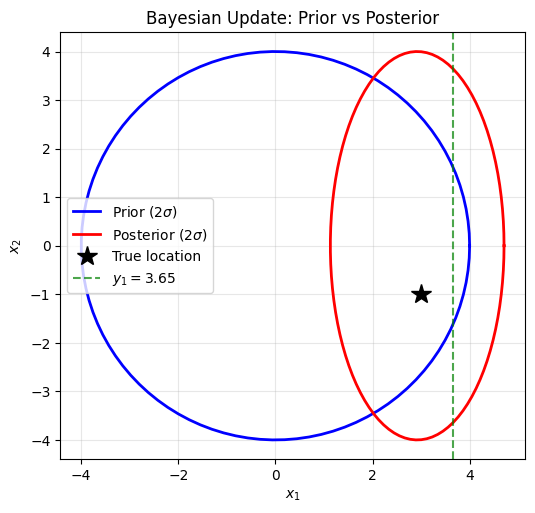

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

# Prior ellipse
pts_prior = ellipse_points(mu_0, Sigma_0)
ax.plot(
    np.asarray(pts_prior[0]),
    np.asarray(pts_prior[1]),
    "b-",
    linewidth=2,
    label="Prior (2$\\sigma$)",
)

# Posterior ellipse
pts_post = ellipse_points(mu_1, Sigma_1)
ax.plot(
    np.asarray(pts_post[0]),
    np.asarray(pts_post[1]),
    "r-",
    linewidth=2,
    label="Posterior (2$\\sigma$)",
)

# True location and observation
ax.plot(*np.asarray(x_true), "k*", markersize=15, label="True location")
ax.axvline(
    float(y_1[0]),
    color="green",
    linestyle="--",
    alpha=0.7,
    label=f"$y_1 = {float(y_1[0]):.2f}$",
)

ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Bayesian Update: Prior vs Posterior")
ax.legend()
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)

plt.show()

## 6. Sequential Updates

We now observe 5 more data points, each time adding the likelihood
natural parameters to the current posterior. The posterior should
shrink around the true location with each new observation.

In [6]:
# Observation matrices: mix of x-only, y-only, and joint observations
H_list = [
    jnp.array([[0.0, 1.0]]),  # y-coordinate
    jnp.array([[1.0, 1.0]]) / jnp.sqrt(2.0),  # diagonal
    jnp.array([[1.0, 0.0]]),  # x-coordinate again
    jnp.array([[0.0, 1.0]]),  # y-coordinate again
    jnp.array([[1.0, -1.0]]) / jnp.sqrt(2.0),  # anti-diagonal
]

R_obs = jnp.array([[0.5]])  # all observations share the same noise

# Simulate observations
observations = []
for H_i in H_list:
    key, subkey = jax.random.split(key)
    y_i = H_i @ x_true + jax.random.normal(subkey, (1,)) * jnp.sqrt(R_obs[0, 0])
    observations.append(y_i)

# Sequential Bayesian updating starting from posterior after first obs
trajectory_mu = [mu_0, mu_1]
trajectory_Sigma = [Sigma_0, Sigma_1]

# Current natural parameters (after first observation)
eta1_curr = eta1_post.copy()
eta2_curr_mat = eta2_post_mat.copy()

R_obs_inv = jnp.linalg.inv(R_obs)

for i, (H_i, y_i) in enumerate(zip(H_list, observations, strict=True)):
    # Likelihood natural parameters
    eta1_lik_i = H_i.T @ R_obs_inv @ y_i
    eta2_lik_i = -0.5 * H_i.T @ R_obs_inv @ H_i

    # Update: just add!
    eta1_curr = eta1_curr + eta1_lik_i
    eta2_curr_mat = eta2_curr_mat + eta2_lik_i

    # Convert back for plotting
    eta2_curr_op = lx.MatrixLinearOperator(eta2_curr_mat, lx.symmetric_tag)
    post_i = GaussianExpFam(eta1=eta1_curr, eta2=eta2_curr_op)
    mu_i, Sigma_i_op = gaussx.to_expectation(post_i)

    trajectory_mu.append(mu_i)
    trajectory_Sigma.append(Sigma_i_op.as_matrix())

    print(f"After obs {i + 2}: mu = [{float(mu_i[0]):.3f}, {float(mu_i[1]):.3f}]")

print(f"\nTrue location: [{float(x_true[0]):.3f}, {float(x_true[1]):.3f}]")

After obs 2: mu = [2.920, -0.632]
After obs 3: mu = [2.991, -0.592]
After obs 4: mu = [3.555, -0.766]
After obs 5: mu = [3.579, -0.865]
After obs 6: mu = [3.556, -0.845]

True location: [3.000, -1.000]


## 7. Sequential Posterior Ellipses

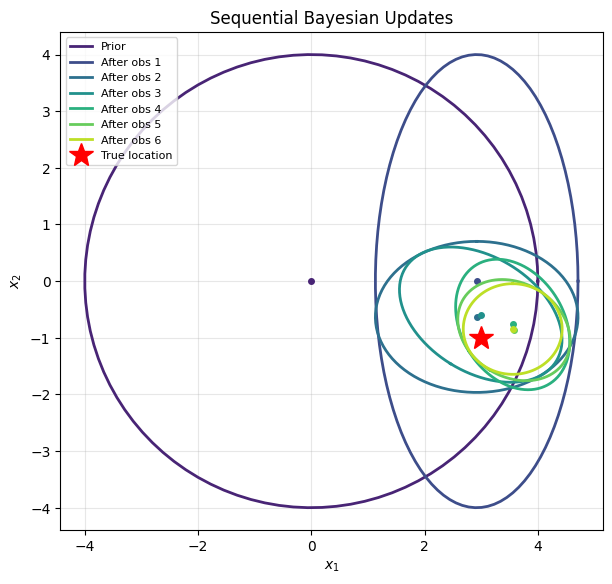

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(7, 7))

n_steps = len(trajectory_mu)
colors = plt.cm.viridis(np.linspace(0.1, 0.9, n_steps))

for k in range(n_steps):
    mu_k = trajectory_mu[k]
    Sigma_k = trajectory_Sigma[k]
    pts = ellipse_points(mu_k, Sigma_k)
    label = "Prior" if k == 0 else f"After obs {k}"
    ax.plot(
        np.asarray(pts[0]),
        np.asarray(pts[1]),
        color=colors[k],
        linewidth=2,
        label=label,
    )
    ax.plot(float(mu_k[0]), float(mu_k[1]), "o", color=colors[k], markersize=4)

ax.plot(*np.asarray(x_true), "r*", markersize=18, label="True location", zorder=10)

ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Sequential Bayesian Updates")
ax.legend(fontsize=8, loc="upper left")
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)

plt.show()

## 8. Batch Update = Sequential Update

Because natural parameters are additive, processing all observations
at once must give the same answer as processing them one at a time.
This is a fundamental property of the exponential family.

In [8]:
# Collect ALL observations (including the first one)
H_all_list = [H_1, *H_list]
y_all_list = [y_1, *observations]
R_all_list = [R_1, *([R_obs] * len(observations))]

# Batch: sum all likelihood natural parameters at once
eta1_batch = eta1_prior.copy()
eta2_batch_mat = eta2_prior.as_matrix().copy()

for H_i, y_i, R_i in zip(H_all_list, y_all_list, R_all_list, strict=True):
    R_i_inv = jnp.linalg.inv(R_i)
    eta1_batch = eta1_batch + H_i.T @ R_i_inv @ y_i
    eta2_batch_mat = eta2_batch_mat + (-0.5 * H_i.T @ R_i_inv @ H_i)

# Convert to mean/cov
eta2_batch_op = lx.MatrixLinearOperator(eta2_batch_mat, lx.symmetric_tag)
batch_expfam = GaussianExpFam(eta1=eta1_batch, eta2=eta2_batch_op)
mu_batch, Sigma_batch_op = gaussx.to_expectation(batch_expfam)
Sigma_batch = Sigma_batch_op.as_matrix()

# Compare with sequential result (last entry in trajectory)
mu_seq = trajectory_mu[-1]
Sigma_seq = trajectory_Sigma[-1]

diff_mu = float(jnp.max(jnp.abs(mu_batch - mu_seq)))
diff_Sigma = float(jnp.max(jnp.abs(Sigma_batch - Sigma_seq)))

print("Batch posterior mean:     ", np.asarray(mu_batch))
print("Sequential posterior mean:", np.asarray(mu_seq))
print(f"Max |mu_batch - mu_seq|     = {diff_mu:.2e}")
print(f"Max |Sigma_batch - Sigma_seq| = {diff_Sigma:.2e}")

Batch posterior mean:      [ 3.55555892 -0.84545955]
Sequential posterior mean: [ 3.55555892 -0.84545955]
Max |mu_batch - mu_seq|     = 0.00e+00
Max |Sigma_batch - Sigma_seq| = 0.00e+00


The batch and sequential results agree to machine precision ($\sim 10^{-15}$),
confirming that natural parameter addition is order-independent.

## 9. Connection to GP Regression

Gaussian process regression **is** Bayes' rule applied to a
function-valued prior:

$$
\text{Prior:} \quad \mathbf{f} \sim \mathcal{GP}(\mathbf{0}, \mathbf{K})
$$

$$
\text{Likelihood:} \quad \mathbf{y} \mid \mathbf{f}
  \sim \mathcal{N}(\mathbf{f},\, \sigma^2 \mathbf{I})
$$

Applying the Gaussian Bayes rule with $\mathbf{H} = \mathbf{I}$
and $\mathbf{R} = \sigma^2 \mathbf{I}$:

$$
\boldsymbol{\Lambda}_{\text{post}}
  = \mathbf{K}^{-1} + \sigma^{-2}\mathbf{I}
$$

$$
\boldsymbol{\mu}_{\text{post}}
  = \boldsymbol{\Lambda}_{\text{post}}^{-1}\,
    \sigma^{-2}\mathbf{y}
  = \mathbf{K}(\mathbf{K} + \sigma^2\mathbf{I})^{-1}\mathbf{y}
$$

This is the standard GP posterior mean formula. We can compute it
directly with `gaussx.solve`.

In [9]:
# Small GP regression example
N_gp = 30
key, subkey = jax.random.split(key)
x_gp = jnp.sort(jax.random.uniform(subkey, (N_gp,), minval=0.0, maxval=5.0))

# RBF kernel
ls = 1.0
diff = x_gp[:, None] - x_gp[None, :]
K_gp = jnp.exp(-0.5 * diff**2 / ls**2)

# Observations with noise
sigma2 = 0.1
key, subkey = jax.random.split(key)
f_true = jnp.sin(x_gp)
y_gp = f_true + jax.random.normal(subkey, (N_gp,)) * jnp.sqrt(sigma2)

# GP posterior via gaussx.solve (the Bayes rule result)
K_plus_noise = K_gp + sigma2 * jnp.eye(N_gp)
K_plus_noise_op = lx.MatrixLinearOperator(K_plus_noise, lx.symmetric_tag)

# mu_post = K (K + sigma^2 I)^{-1} y
alpha = gaussx.solve(K_plus_noise_op, y_gp)
mu_gp_post = K_gp @ alpha

# Also compute the log marginal likelihood
lml = gaussx.log_marginal_likelihood(
    loc=jnp.zeros(N_gp),
    cov_operator=K_plus_noise_op,
    y=y_gp,
)

print(f"GP log marginal likelihood: {float(lml):.3f}")
rmse = float(jnp.sqrt(jnp.mean((mu_gp_post - f_true) ** 2)))
print(f"Posterior mean RMSE vs truth: {rmse:.4f}")

GP log marginal likelihood: -22.574
Posterior mean RMSE vs truth: 0.1223


The GP posterior mean is just the Bayes rule result computed via a
single `gaussx.solve` call. The log marginal likelihood -- used for
hyperparameter optimisation -- is computed by
`gaussx.log_marginal_likelihood`, which internally uses `solve` and
`logdet` on the same structured operator.

## 10. Summary

Bayes' rule for Gaussians is **addition in natural parameter space**:

$$
\eta_{\text{post}} = \eta_{\text{prior}} + \eta_{\text{lik}}
$$

This single insight underlies:

- **Kalman filtering** (sequential state estimation)
- **GP regression** (function-space inference)
- **Variational inference** with Gaussian approximations
- **Natural gradient** methods

gaussx makes this clean with:

- `to_natural` / `to_expectation` for parameter conversion
- `GaussianExpFam` for natural parameter containers
- `solve`, `inv`, `logdet` for structured linear algebra
- `log_marginal_likelihood` for GP model selection

All operations compose naturally with JAX's `jit`, `grad`, and `vmap`.

## References

- Bernardo, J. M. & Smith, A. F. M. (2000). *Bayesian Theory*. Wiley.
- Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*.
  Springer. (Section 2.3)
- Rasmussen, C. E. & Williams, C. K. I. (2006). *Gaussian Processes for
  Machine Learning*. MIT Press.
- Minka, T. P. (2001). *A Family of Algorithms for Approximate Bayesian
  Inference*. PhD thesis, MIT.
- Opper, M. & Winther, O. (2005). Expectation consistent approximate
  inference. *JMLR*, 6, 2177--2204.